In [6]:
import mne
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")
mne.set_log_level('WARNING')

In [7]:
# --- Configuration ---

# Path to the new folder with labeled epochs
data_folder = "/Volumes/T9/Circling_dataset/Epochs_labeled"

# --- Select a band and channel to focus on for the plots ---
# (You can easily change these and re-run)
BAND_TO_PLOT = "beta"
CHANNEL_TO_PLOT = "C3"

# ---

In [8]:
all_metadata_list = []

# Find all epoch files in the directory
epoch_files = glob.glob(os.path.join(data_folder, "pair*epo.fif"))
print(f"Found {len(epoch_files)} epoch files to process...")

for f_path in epoch_files:
    try:
        # Get a unique subject ID from the filename
        # e.g., "pair2010_a"
        f_name = os.path.basename(f_path)
        subject_id = f_name.split('-epo.fif')[0]
        
        # Read the epochs file
        epochs = mne.read_epochs(f_path, preload=False)
        
        # Get the metadata
        metadata = epochs.metadata
        
        # Add the subject ID to the metadata
        metadata['subject_id'] = subject_id
        
        # Append to our master list
        all_metadata_list.append(metadata)
        
    except Exception as e:
        print(f"Error processing {f_path}: {e}")

# Concatenate all DataFrames into one
df = pd.concat(all_metadata_list, ignore_index=True)

print("\nDone.")
print(f"Total epochs aggregated: {len(df)}")
print(f"Total subjects aggregated: {df['subject_id'].nunique()}")
print("\nAggregated DataFrame (sample):")
df.head()

Found 104 epoch files to process...

Done.
Total epochs aggregated: 5860
Total subjects aggregated: 104

Aggregated DataFrame (sample):


,autoreject_bad,theta_Fp1,theta_AF7,theta_AF3,theta_F1,theta_F3,theta_F5,theta_F7,theta_FT7,theta_FC5,...,spec_beta_CP2,spec_beta_P2,spec_beta_P4,spec_beta_P6,spec_beta_P8,spec_beta_P10,spec_beta_PO8,spec_beta_PO4,spec_beta_O2,subject_id
0,False,2.718000e-07,1.386000e-07,4.205000e-07,7.862000e-07,4.213000e-07,6.405000e-07,3.455000e-07,5.233000e-07,7.932000e-07,...,-0.226990,0.200749,-0.522918,-0.350346,-0.314662,-0.006668,-0.191004,-0.383623,-0.441187,pair2010_a
1,False,5.745000e-07,4.023000e-07,8.262000e-07,1.058500e-06,8.675000e-07,5.052000e-07,1.776000e-07,1.554000e-07,2.962000e-07,...,0.262951,0.563423,0.235721,0.474955,1.503302,0.917340,1.476972,0.064688,1.351857,pair2010_a
2,False,2.865000e-07,2.450000e-07,2.304000e-07,4.065000e-07,2.681000e-07,4.114000e-07,2.958000e-07,1.665000e-07,4.095000e-07,...,-0.440929,0.038566,0.201621,0.065753,0.840637,1.191054,0.711661,0.898476,0.062197,pair2010_a
3,False,3.217000e-07,2.946000e-07,2.588000e-07,3.602000e-07,2.733000e-07,3.751000e-07,2.461000e-07,2.216000e-07,2.297000e-07,...,-0.124789,0.383343,0.294652,0.181041,1.036329,1.225335,-0.576207,-0.045373,-1.154346,pair2010_a
4,False,3.778000e-07,1.837000e-07,6.311000e-07,1.263900e-06,8.970000e-07,4.465000e-07,2.093000e-07,2.650000e-07,3.241000e-07,...,-0.167726,0.026369,-0.009054,-0.001551,-0.500704,-1.272650,-1.574790,0.282066,-1.081705,pair2010_a


In [9]:
# Create the column name based on our configuration
col_to_plot = f"spec_{BAND_TO_PLOT}_{CHANNEL_TO_PLOT}"

print(f"Will focus on column: {col_to_plot}")

# Check if column exists
if col_to_plot not in df.columns:
    print(f"ERROR: Column '{col_to_plot}' not found in DataFrame.")
    print("Available columns (sample):")
    print(df.columns[10:20].tolist())

Will focus on column: spec_beta_C3


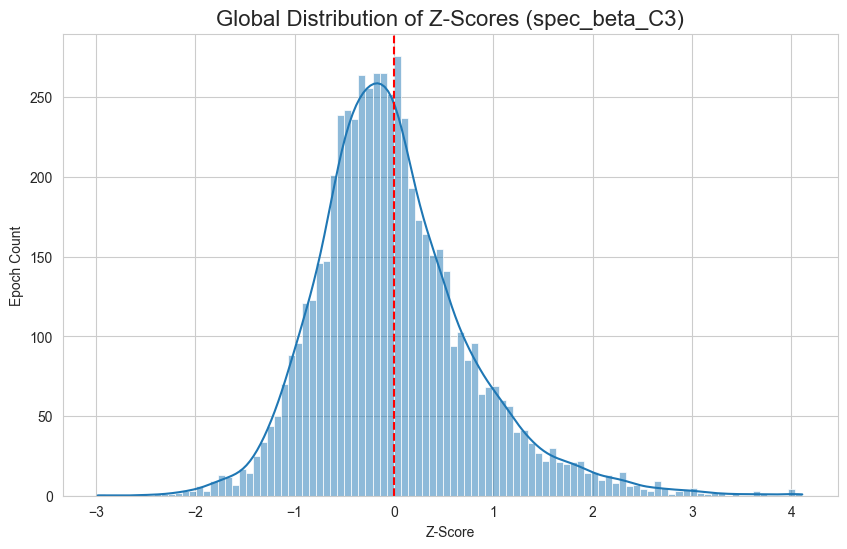

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df[col_to_plot], bins=100, kde=True)
plt.title(f"Global Distribution of Z-Scores ({col_to_plot})", fontsize=16)
plt.xlabel("Z-Score")
plt.ylabel("Epoch Count")
plt.axvline(0, color='red', linestyle='--', label='Mean (0.0)')
plt.show()

Plotting 104 subjects in a 21x5 grid...


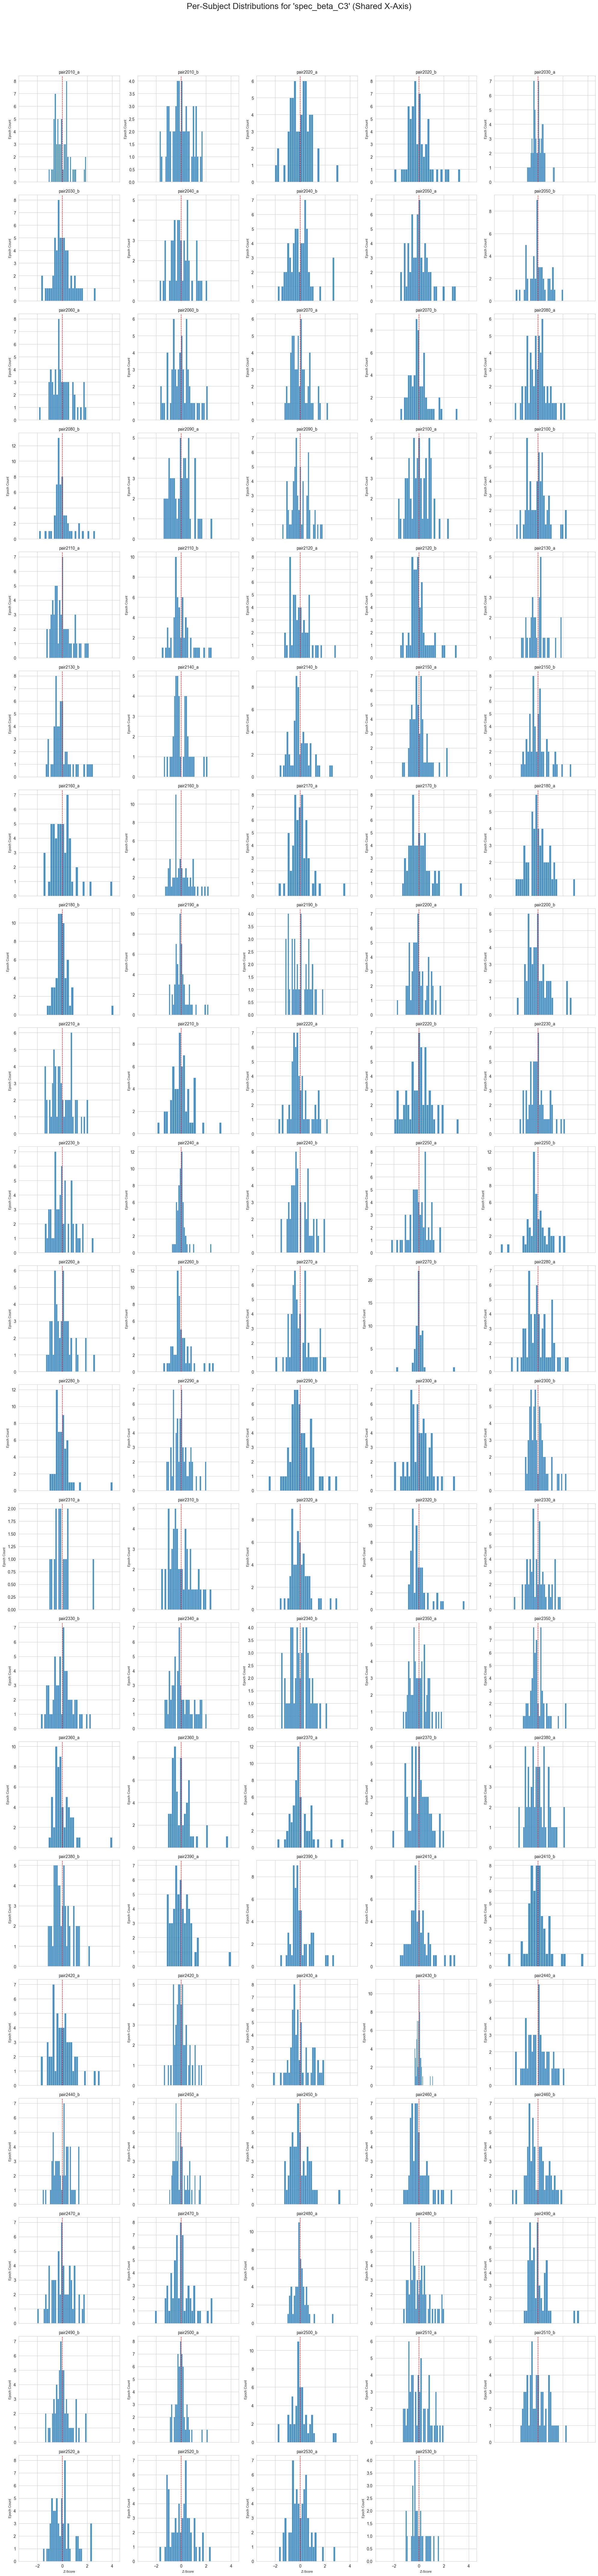

In [11]:
# --- Get all unique subjects ---
all_subjects = sorted(df['subject_id'].unique())
n_subjects = len(all_subjects)

# --- Determine shared x-axis range ---
global_min = df[col_to_plot].min()
global_max = df[col_to_plot].max()
# Add a little padding
x_range = (global_min - 0.5, global_max + 0.5)

# --- Set up the subplot grid ---
# We'll use 5 columns, and as many rows as needed
n_cols = 5
# Calculate rows needed: (total_subjects + columns - 1) // columns
n_rows = (n_subjects + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4), sharex=True)
# Flatten the axes array to make looping easier
axes = axes.flatten()

print(f"Plotting {n_subjects} subjects in a {n_rows}x{n_cols} grid...")

for i, subject_id in enumerate(all_subjects):
    ax = axes[i]
    
    # Filter data for this subject
    subject_data = df[df['subject_id'] == subject_id]
    
    # Plot histogram for this subject
    sns.histplot(subject_data[col_to_plot], bins=30, kde=False, ax=ax, alpha=0.8)
    
    ax.set_title(subject_id, fontsize=10)
    ax.set_ylabel("Epoch Count", fontsize=8)
    ax.set_xlabel("Z-Score", fontsize=8)
    
    # Set the shared x-axis
    ax.set_xlim(x_range)
    
    # Add a red line for the subject's own mean
    ax.axvline(subject_data[col_to_plot].mean(), color='red', linestyle='--', linewidth=1)

# --- Hide any unused subplots ---
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Per-Subject Distributions for '{col_to_plot}' (Shared X-Axis)", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

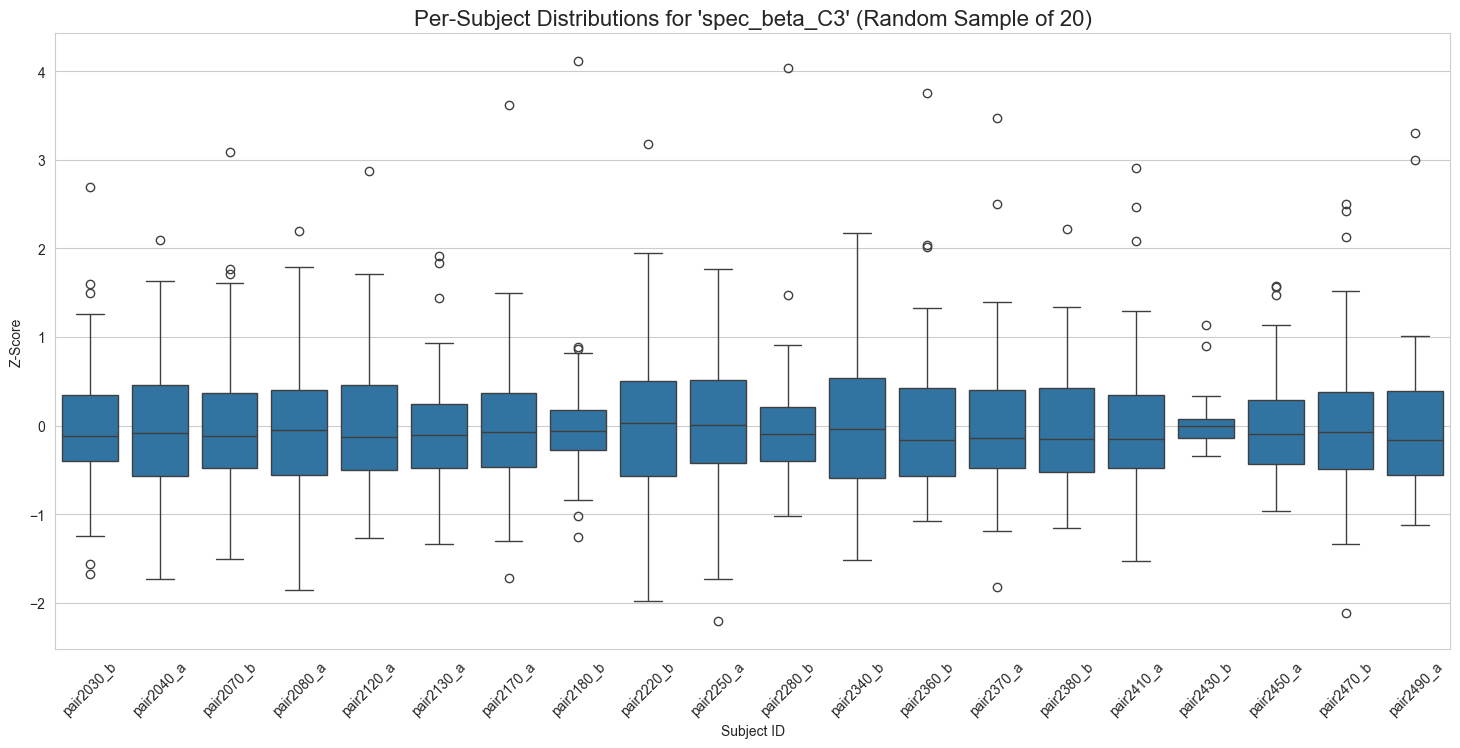

In [12]:
# Get a random subset of subjects to plot (100+ is unreadable)
n_subjects_to_plot = 20
all_subjects = df['subject_id'].unique()
subjects_to_plot = np.random.choice(all_subjects, n_subjects_to_plot, replace=False)

# Filter the DataFrame
df_subset = df[df['subject_id'].isin(subjects_to_plot)]

# Plot
plt.figure(figsize=(18, 8))
sns.boxplot(data=df_subset, x='subject_id', y=col_to_plot)
plt.title(f"Per-Subject Distributions for '{col_to_plot}' (Random Sample of {n_subjects_to_plot})", fontsize=16)
plt.xlabel("Subject ID")
plt.ylabel("Z-Score")
plt.xticks(rotation=45)
plt.show()

Found 401 epochs matching the concept (spec_beta_C3 < -1.0)


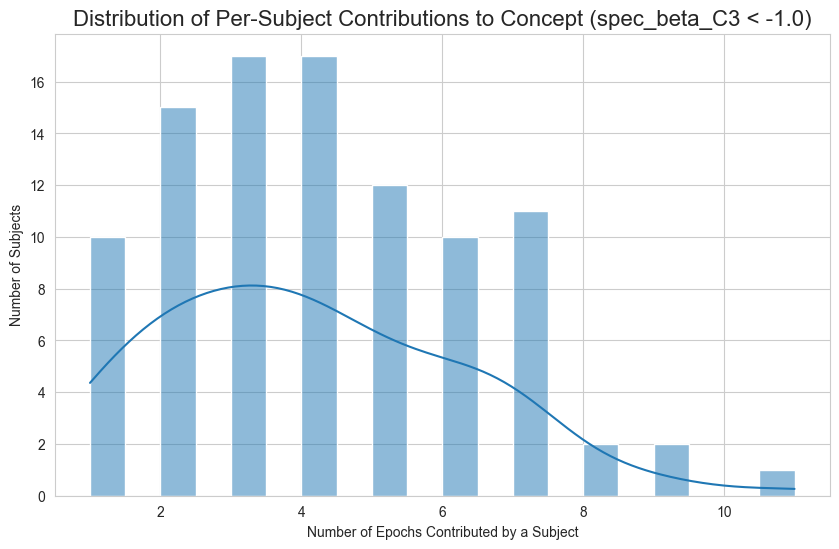


--- Contribution Statistics ---
Total subjects who contributed 0 epochs: 7
Total subjects who contributed at least 1 epoch: 97

Subject contributing the most epochs:
subject_id
pair2220_b    11
Name: count, dtype: int64

Subject contributing the fewest (non-zero) epochs:
subject_id
pair2010_a    1
Name: count, dtype: int64


In [13]:
# --- Define your "concept" threshold ---
CONCEPT_THRESHOLD = -1.0

# Filter for epochs that match the concept
df_concept = df[df[col_to_plot] < CONCEPT_THRESHOLD]
print(f"Found {len(df_concept)} epochs matching the concept ({col_to_plot} < {CONCEPT_THRESHOLD})")

# Count how many epochs each subject contributed
contribution_counts = df_concept['subject_id'].value_counts()

# --- Plot the distribution of contributions ---
plt.figure(figsize=(10, 6))
sns.histplot(contribution_counts, bins=20, kde=True)
plt.title(f"Distribution of Per-Subject Contributions to Concept ({col_to_plot} < {CONCEPT_THRESHOLD})", fontsize=16)
plt.xlabel("Number of Epochs Contributed by a Subject")
plt.ylabel("Number of Subjects")
plt.show()

print("\n--- Contribution Statistics ---")
print(f"Total subjects who contributed 0 epochs: {len(all_subjects) - len(contribution_counts)}")
print(f"Total subjects who contributed at least 1 epoch: {len(contribution_counts)}")
print(f"\nSubject contributing the most epochs:")
print(contribution_counts.head(1))
print(f"\nSubject contributing the fewest (non-zero) epochs:")
print(contribution_counts.tail(1))